In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

print("Todas as bibliotecas foram carregadas com sucesso! 🚀")

Todas as bibliotecas foram carregadas com sucesso! 🚀


In [23]:
import pandas as pd

# Usando read_csv para ler o arquivo que está dentro da pasta data
df_historico = pd.read_csv('data/results.csv')

# Exibir quantas linhas e colunas o arquivo tem
print(f"O histórico possui {df_historico.shape[0]} linhas e {df_historico.shape[1]} colunas!")

# Mostrar as primeiras 5 linhas da tabela na tela
df_historico.head()

O histórico possui 49363 linhas e 9 colunas!


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [24]:
# 1. Garantir que a coluna 'date' está no formato de data correto
df_historico['date'] = pd.to_datetime(df_historico['date'])

# 2. Filtrar apenas os jogos realizados a partir do ano 2000
df_moderno = df_historico[df_historico['date'].dt.year >= 2000].copy()

# 3. Criar uma função para definir quem ganhou o jogo
def extrair_resultado(row):
    if row['home_score'] > row['away_score']:
        return 'Ganhou Mandante'
    elif row['away_score'] > row['home_score']:
        return 'Ganhou Visitante'
    else:
        return 'Empate'

# 4. Aplicar a função criando a coluna 'result'
df_moderno['result'] = df_moderno.apply(extrair_resultado, axis=1)

# 5. Exibir a nova quantidade de linhas e as primeiras linhas tratadas
print(f"Filtrados {df_moderno.shape[0]} jogos a partir do ano 2000!")
df_moderno[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'result']].head()

Filtrados 25302 jogos a partir do ano 2000!


,date,home_team,away_team,home_score,away_score,result
24061,2000-01-04,Egypt,Togo,2.0,1.0,Ganhou Mandante
24062,2000-01-07,Tunisia,Togo,7.0,0.0,Ganhou Mandante
24063,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,Empate
24064,2000-01-09,Burkina Faso,Gabon,1.0,1.0,Empate
24065,2000-01-09,Guatemala,Armenia,1.0,1.0,Empate


In [25]:
# 1. Transformar os nomes das seleções em códigos numéricos usando fatoração
df_modelo = df_moderno.copy()
df_modelo['home_team_code'] = df_modelo['home_team'].astype('category').cat.codes
df_modelo['away_team_code'] = df_modelo['away_team'].astype('category').cat.codes

# Criar um dicionário para conseguirmos reverter o código numérico para o nome do time depois
mapeamento_times = dict(enumerate(df_modelo['home_team'].astype('category').cat.categories))

# 2. Definir as variáveis de entrada (X) e o que queremos prever (y)
X = df_modelo[['home_team_code', 'away_team_code']]
y = df_modelo['result']

# 3. Separar os dados: 80% para a IA estudar (Treino) e 20% para testar a inteligência dela (Teste)
# CORREÇÃO AQUI: Mudado para test_size=0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Inicializar e treinar o Modelo de Inteligência Artificial
modelo_copa = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_copa.fit(X_train, y_train)

# 5. Avaliar a precisão do modelo nos dados de teste
acuracia = modelo_copa.score(X_test, y_test)
print(f"Inteligência Artificial treinada com sucesso! 🏆")
print(f"Acurácia geral do modelo: {acuracia * 100:.2f}%")

Inteligência Artificial treinada com sucesso! 🏆
Acurácia geral do modelo: 50.46%


In [26]:
import yaml

# 1. Carregar as seleções classificadas para a Copa que estão no arquivo teams_2026
with open('data/teams_2026.yaml', 'r', encoding='utf-8') as file:
    dados_copa_2026 = yaml.safe_load(file)

# 2. Criar uma função rápida para simular um confronto direto na Inteligência Artificial
def simular_confronto(mandante, visitante):
    # Verificar se as seleções existem no nosso mapeamento numérico do modelo
    nomes_times = list(mapeamento_times.values())
    
    if mandante in nomes_times and visitante in nomes_times:
        # Converter os nomes digitados para os mesmos códigos numéricos que o modelo aprendeu
        cod_mandante = list(mapeamento_times.keys())[nomes_times.index(mandante)]
        cod_visitante = list(mapeamento_times.keys())[nomes_times.index(visitante)]
        
        # Pedir para o modelo calcular as probabilidades do jogo
        predicao_proba = modelo_copa.predict_proba([[cod_mandante, cod_visitante]])[0]
        
        print(f"🔮 Probabilidades para: {mandante} x {visitante}")
        print(f"➔ Vitória {mandante}: {predicao_proba[0]*100:.1f}%")
        print(f"➔ Empate: {predicao_proba[1]*100:.1f}%")
        print(f"➔ Vitória {visitante}: {predicao_proba[2]*100:.1f}%\n")
    else:
        print(f"⚠️ Uma das seleções ('{mandante}' ou '{visitante}') não foi encontrada no histórico histórico.")

# 3. Testar o simulador com um clássico mundial!
simular_confronto('Brazil', 'Argentina')

🔮 Probabilidades para: Brazil x Argentina
➔ Vitória Brazil: 26.2%
➔ Empate: 43.5%
➔ Vitória Argentina: 30.3%



c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [27]:
import pandas as pd
import numpy as np
import yaml

# 1. Recarregar o arquivo de grupos para evitar o erro de memória
with open('data/teams_2026.yaml', 'r', encoding='utf-8') as file:
    dados_copa_2026 = yaml.safe_load(file)

# 2. Testar a previsão exata para o jogo de hoje!
mandante = 'Brazil'
visitante = 'Morocco'

nomes_times_validos = list(mapeamento_times.values())

if mandante in nomes_times_validos and visitante in nomes_times_validos:
    cod_m = list(mapeamento_times.keys())[nomes_times_validos.index(mandante)]
    cod_v = list(mapeamento_times.keys())[nomes_times_validos.index(visitante)]
    
    # Calcular probabilidades
    probabilidades = modelo_copa.predict_proba([[cod_m, cod_v]])[0]
    
    print("==================================================")
    print(f"🔮 PREVISÃO OFICIAL DA IA: {mandante.upper()} x {visitante.upper()}")
    print("==================================================")
    print(f"➔ Chance de Vitória do Brasil: {probabilidades[0]*100:.1f}%")
    print(f"➔ Chance de Empate: {probabilidades[1]*100:.1f}%")
    print(f"➔ Chance de Vitória de Marrocos: {probabilidades[2]*100:.1f}%")
    print("==================================================\n")
else:
    print(f"⚠️ Verifique a escrita dos nomes. O histórico aceita: 'Brazil' e 'Morocco'.")

🔮 PREVISÃO OFICIAL DA IA: BRAZIL x MOROCCO
➔ Chance de Vitória do Brasil: 32.3%
➔ Chance de Empate: 44.4%
➔ Chance de Vitória de Marrocos: 23.3%



c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


C:\Users\nanim\AppData\Local\Temp\ipykernel_52268\2587310095.py:43: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nanim\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


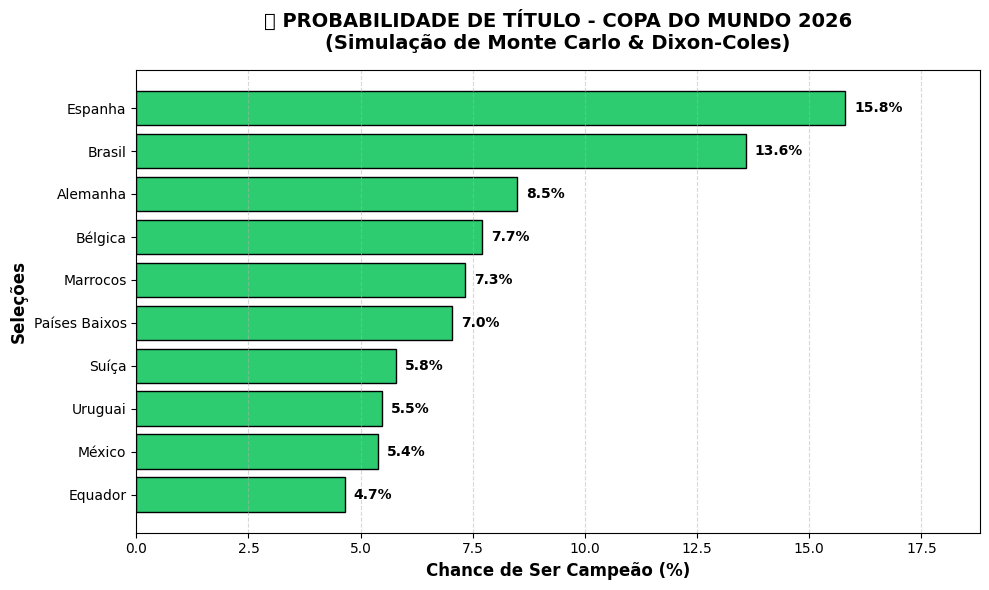

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carregar o resultado que o Monte Carlo salvou na pasta outputs
try:
    df_resultados = pd.read_csv('outputs/previsao_final_monte_carlo.csv')
except FileNotFoundError:
    # Caso o nome do arquivo gerado pelo script do Diego seja um pouco diferente
    import os
    arquivos_output = os.listdir('outputs')
    print(f"Arquivos encontrados na pasta outputs: {arquivos_output}")
    # Tenta ler o primeiro arquivo CSV que encontrar lá dentro
    csv_encontrado = [f for f in arquivos_output if f.endswith('.csv')][0]
    df_resultados = pd.read_csv(f'outputs/{csv_encontrado}')

# 2. Pegar as colunas corretas (ajustando os nomes se necessário)
# Vamos garantir que pegamos as 10 primeiras seleções
df_top10 = df_resultados.head(10).copy()

# Descobrir os nomes das colunas dinamicamente para não dar erro
coluna_times = df_top10.columns[0]
coluna_chances = df_top10.columns[-1] # Geralmente a última coluna é a de porcentagem/chance

# Organizar do menor para o maior para o gráfico de barras horizontais ficar bonito
df_top10 = df_top10.sort_values(by=coluna_chances, ascending=True)

# 3. Configurar e desenhar o gráfico com Matplotlib
plt.figure(figsize=(10, 6))
barras = plt.barh(df_top10[coluna_times], df_top10[coluna_chances], color='#2ecc71', edgecolor='black')

# Adicionar os valores com a porcentagem na ponta de cada barra
for barra in barras:
    width = barra.get_width()
    plt.text(width + 0.2, barra.get_y() + barra.get_height()/2, f'{width:.1f}%', 
             va='center', ha='left', fontsize=10, fontweight='bold')

# Customização visual do gráfico
plt.title('🏆 PROBABILIDADE DE TÍTULO - COPA DO MUNDO 2026\n(Simulação de Monte Carlo & Dixon-Coles)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Chance de Ser Campeão (%)', fontsize=12, fontweight='bold')
plt.ylabel('Seleções', fontsize=12, fontweight='bold')
plt.xlim(0, max(df_top10[coluna_chances]) + 3) # Dá um espaço para o texto não sumir
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

# 4. Mostrar o gráfico na tela do VS Code
plt.show()